# Customer Lifetime Value (CLTV) Exploratory Analysis

## Executive Summary
**Project Goal:** To identify key behavioral and demographic factors influencing Customer Lifetime Value (CLTV) to inform business retention and acquisition strategies.

### 1. Key Insights
* **The Zero-Claim Opportunity:** Our analysis revealed a bimodal customer base. A vast majority of our high-value customers have filed **zero claims**. This identifies "Low-Risk/High-Value" as our most profitable segment.

* **Income Paradox:** Contrary to intuition, the highest average CLTV is not found in our highest-income bracket, but in our moderate and lower-income brackets. This indicates that our product portfolio is currently optimized for value-conscious segments rather than premium-income segments.
* **Demographic Alignment:** Urban areas and Platinum-tier policies represent our highest volume and value, indicating that current marketing success is highly concentrated in urban hubs.

### 2. Strategic Recommendations
* **Segmented Marketing:** Launch a loyalty campaign specifically targeting the `Zero-Claim` segment to maintain their low-risk status.
* **Review Premium Products:** Investigate why the `More than 10L` income segment has a lower CLTV; we may be missing the "premium" value proposition required to capture this group's potential.
* **Refine Risk Pricing:** The `Others` qualification group shows significantly lower CLTV. Future models should investigate if this is a result of higher claim frequency or lower policy retention in this group.

# Reading the Data

In [ ]:
import os
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(os.path.join('..')))
train = pd.read_csv("../data/raw/train_BRCpofr.csv.zip", compression="zip")
test = pd.read_csv("../data/raw/test_koRSKBP.csv.zip", compression="zip")

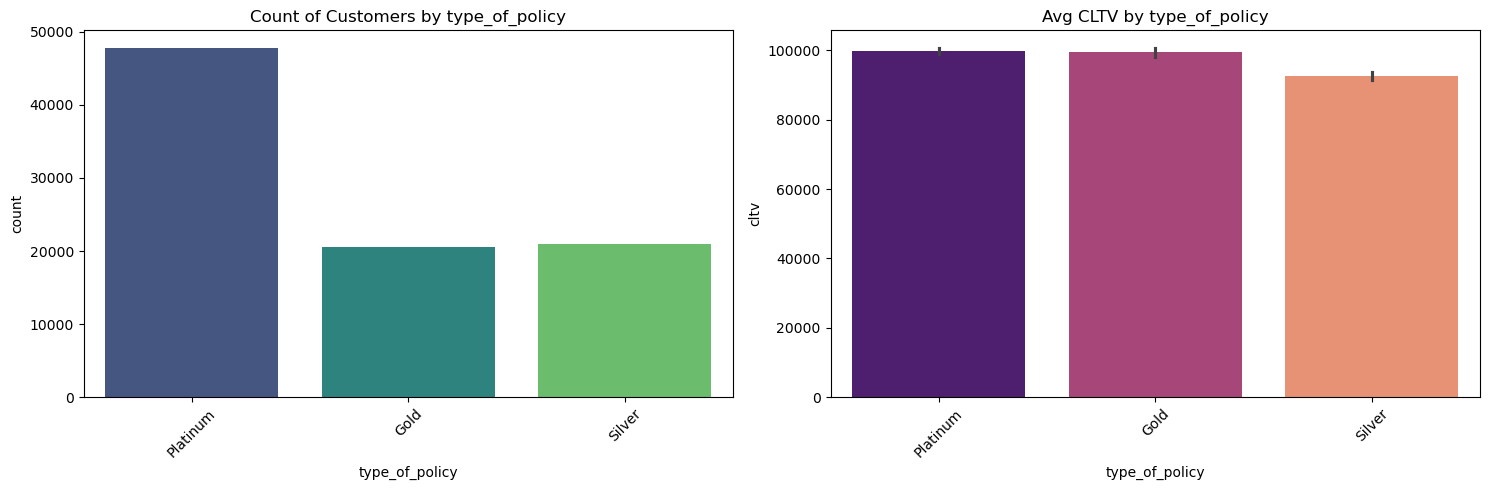

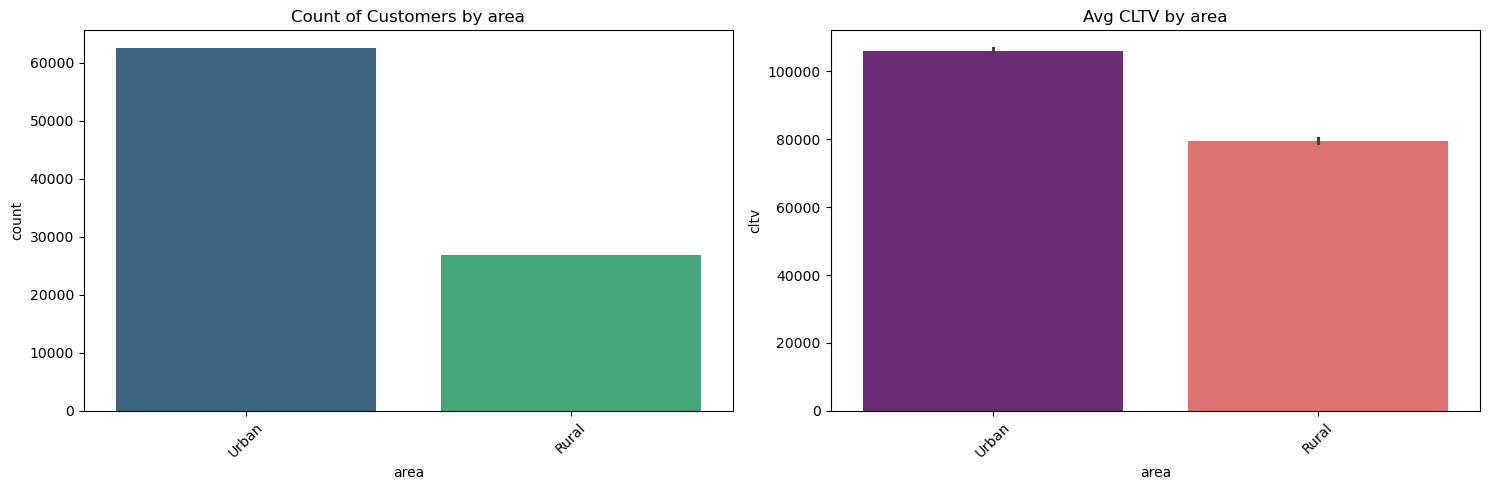

In [ ]:
def analyze_categorical(df, col, target='cltv'):
    """
    Creates a dual-plot analysis:
    1. Count of customers per category
    2. Average CLTV per category
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Plot 1: Distribution
    sns.countplot(data=df, x=col, ax=axes[0], palette='viridis', hue=col)
    axes[0].set_title(f'Count of Customers by {col}')
    axes[0].tick_params(axis='x', rotation=45)

    # Plot 2: Average CLTV
    sns.barplot(data=df, x=col, y=target, ax=axes[1], palette='magma', hue=col)
    axes[1].set_title(f'Avg CLTV by {col}')
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()


# Now call it for your key columns
analyze_categorical(train, 'type_of_policy')
analyze_categorical(train, 'area')

In [47]:


def plot_categorical_insight(data, feature):
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Left plot: Volume
    sns.countplot(data=data, x=feature,
                  ax=axes[0], palette='viridis', hue=feature)
    axes[0].set_title(f"Customer Distribution by {feature}", fontsize=14)
    axes[0].tick_params(axis='x', rotation=45)

    # Right plot: Value
    sns.barplot(data=data, x=feature, y='cltv',
                ax=axes[1], palette='magma', hue=feature)
    axes[1].set_title(f"Average CLTV by {feature}", fontsize=14)
    axes[1].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

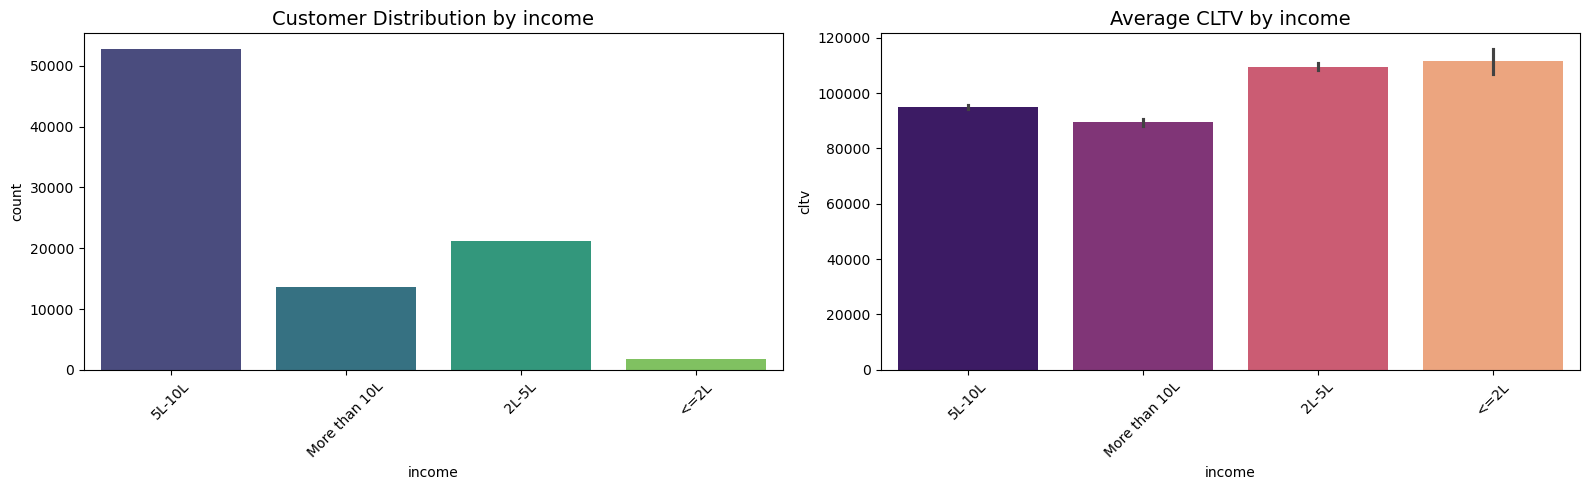

In [48]:
plot_categorical_insight(train, 'income')

While the 5L-10L has the highest customer volumes, 2L-5L and <=2L customers has the highest the highest average customer lifetime value.
This shows that the wealthy customers are not the highest value customer. The low income customers might be more loyal or tend to buy more specific high margin packages.

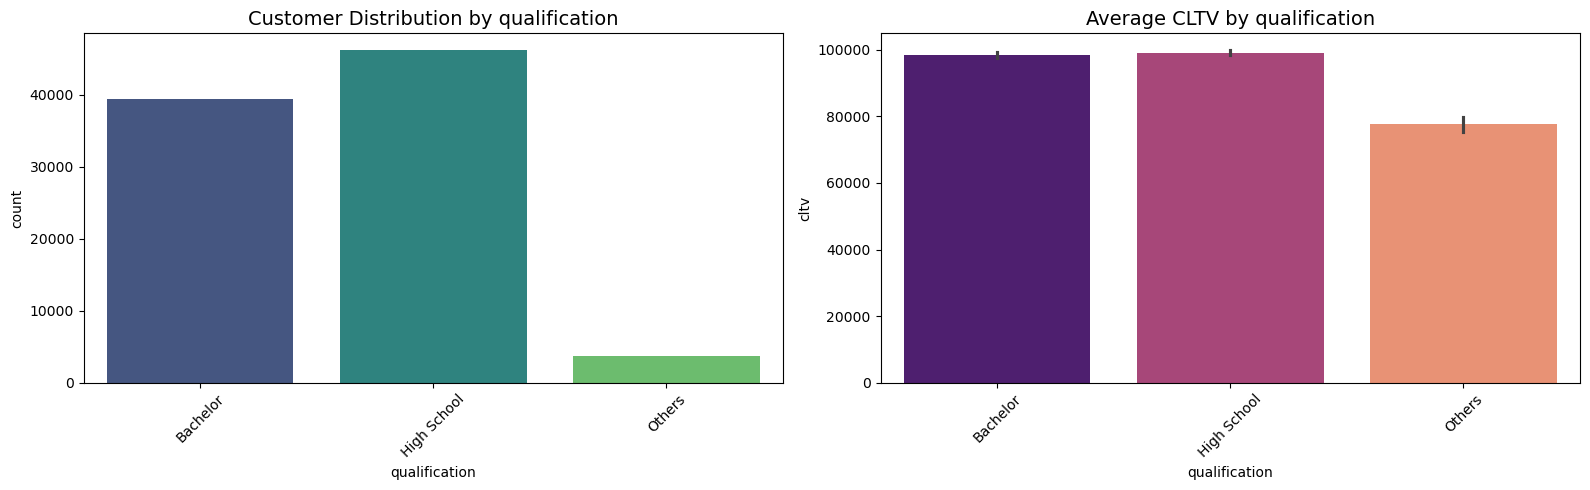

In [49]:
plot_categorical_insight(train, 'qualification')

Bachelor and High School groups have almost identical average CLTVs, but the Others category significantly underperforms. 
The product tends to the general public but  might need a tailored marketing approach to stimulate Others category.

## Analysis: Socio-Economic Drivers of CLTV
* Key Finding: Income brackets do not follow a linear relationship with CLTV. Surprisingly, lower-income segments (<=2L) demonstrate higher lifetime value than the high-volume 5L-10L segment.

* Business Implication: This suggests that current acquisition strategies might be over-indexing on high-income segments that are less profitable in the long run. We should investigate if this is due to product fit or retention rates in the <=2L group.

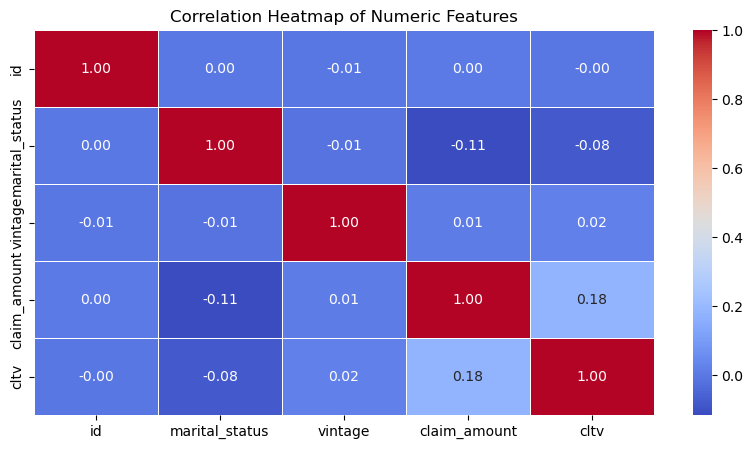

In [50]:
# Select only numeric columns
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(10, 5))
sns.heatmap(train[numeric_cols].corr(), annot=True,
            cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

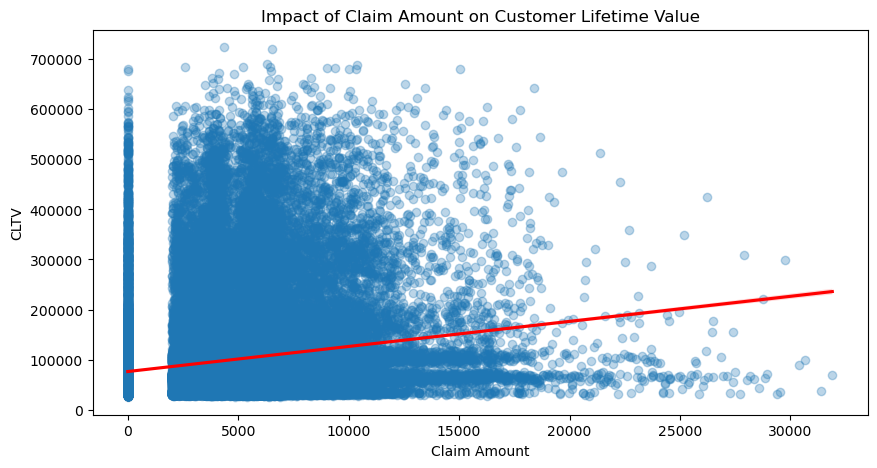

In [51]:
plt.figure(figsize=(10, 5))
sns.regplot(data=train, x='claim_amount', y='cltv',
            scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
plt.title("Impact of Claim Amount on Customer Lifetime Value")
plt.xlabel("Claim Amount")
plt.ylabel("CLTV")
plt.show()

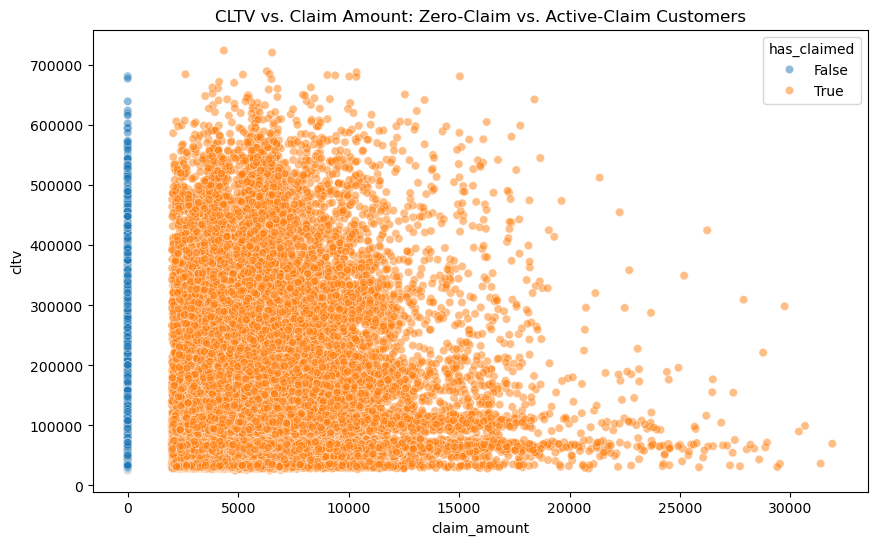

In [52]:
# Create a binary column for the plot
train['has_claimed'] = (train['claim_amount'] > 0)

# Use Seaborn to color-code the groups
plt.figure(figsize=(10, 6))
sns.scatterplot(data=train, x='claim_amount',
                y='cltv', hue='has_claimed', alpha=0.5)
plt.title("CLTV vs. Claim Amount: Zero-Claim vs. Active-Claim Customers")
plt.show()

### *The "Zero-Claim" vs "Active-Claim" Profile*
we can see that there are two groups of customers in these plots
#### Group A: claim_amount == 0
* These are the low risk customers
* They have not make any claim and are consistently loyal.
#### Group B: claim_amount > 0
* Theses are customers who have make claims greaater than 0
* They are high risk customers.